# Robust analysis

## Loading the data

In [2]:
import numpy as np

kiwi_spectra = np.loadtxt("results/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt("data/reference.csv", delimiter=",")
wl = np.loadtxt("results/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]
reference_values = np.expand_dims(reference_values, axis=1)
reference_values.shape

(180, 1)

## Pre-processing

In [3]:
import nippy

preprocessing_pipeline = {'MSC': None, 
                          'SAVGOL': 
                          {'deriv_order': 2, 
                           'filter_win': 13, 
                           'poly_order': 2}, 
                           'SNV': {}}

wl, kiwi_spectra_processed = nippy.run_pipeline(wl, kiwi_spectra.T, preprocessing_pipeline)
kiwi_spectra_processed = kiwi_spectra_processed.T

## Data partition

In [4]:
import kennard_stone as ks

X_cal_ks, X_test_ks, y_cal_ks, y_test_ks = ks.train_test_split(kiwi_spectra_processed, reference_values, test_size = 0.2)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-07-01 14:45:44,571 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-07-01 14:45:44,573 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Robust PCA

PCA is very susceptible to the outliers. If we modify just one sample the results already are going to be quite different.

In [5]:
import matplotlib.pyplot as plt
 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [6]:
X_copy = np.copy(X_cal_ks)
X_copy[0,:] = X_copy[0,:]**2 + X_copy[0,:] * 12

In [7]:
pipe1 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA(random_state=42))])
pipe2 = Pipeline([('scaler', StandardScaler(with_std=False)), ('pca', PCA(random_state=42))])
 
pipe1.fit(X_cal_ks)
pipe2.fit(X_copy)

Pipeline(steps=[('scaler', StandardScaler(with_std=False)),
                ('pca', PCA(random_state=42))])

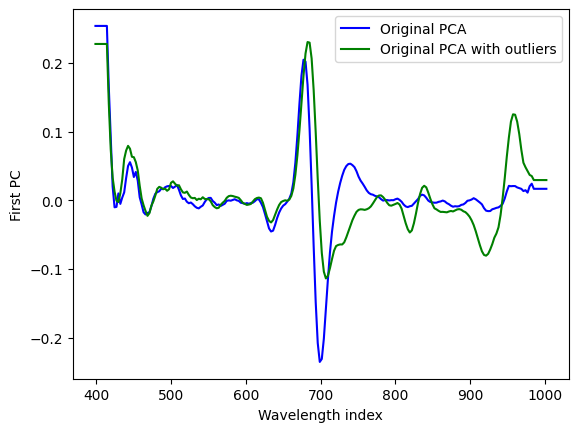

In [8]:
plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(wl, pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()

If we use robust way of estimating covariance, we can mitigate the effects of outliers.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


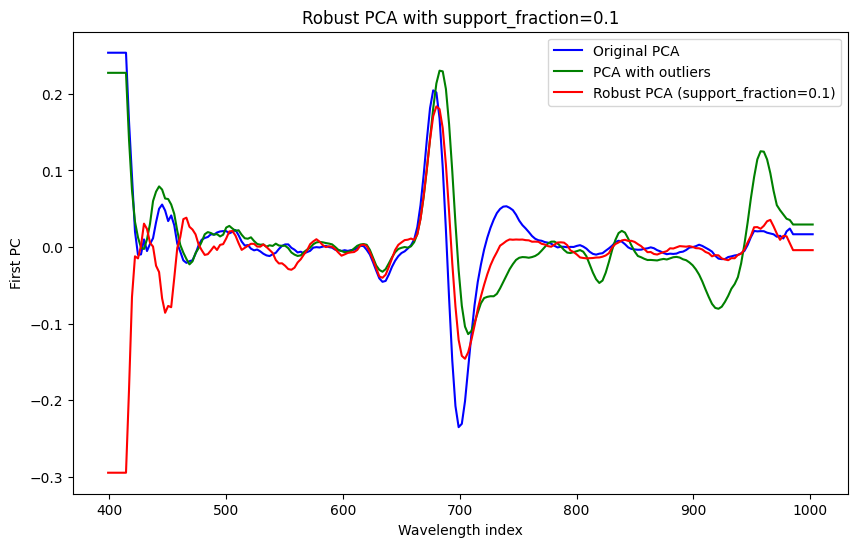

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


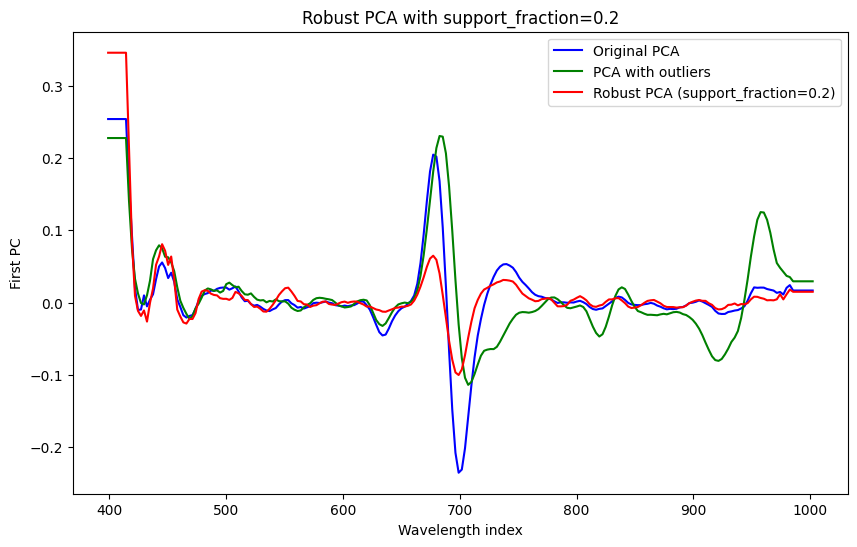

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


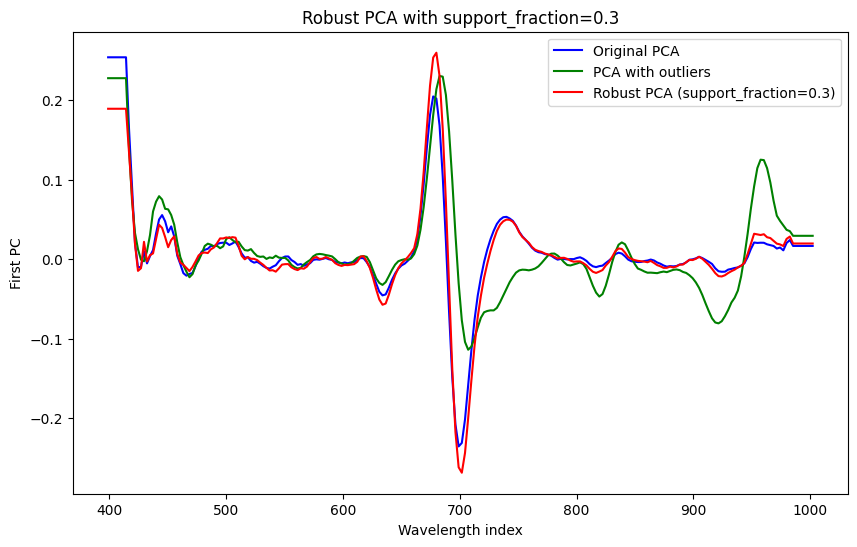

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


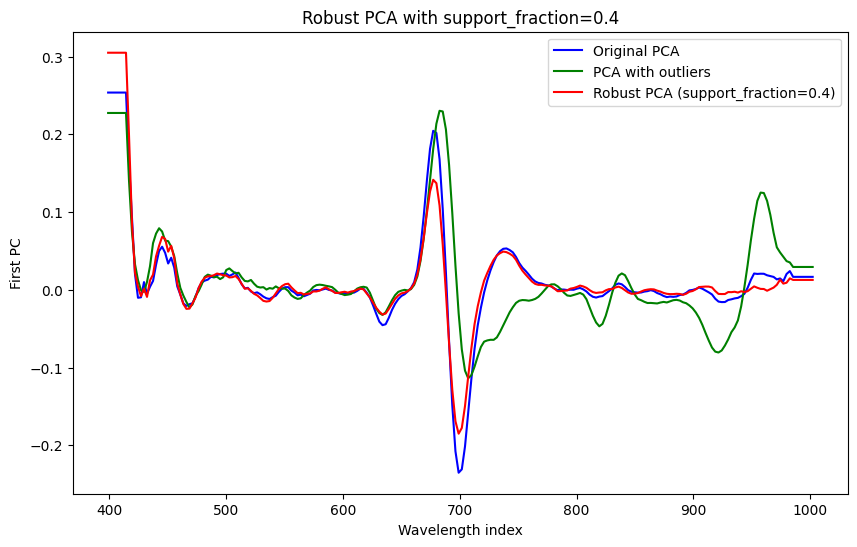

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


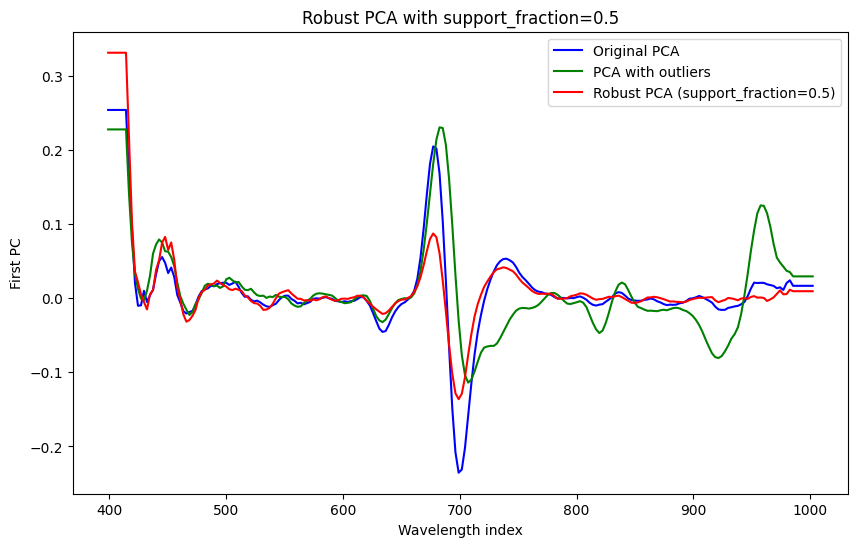

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


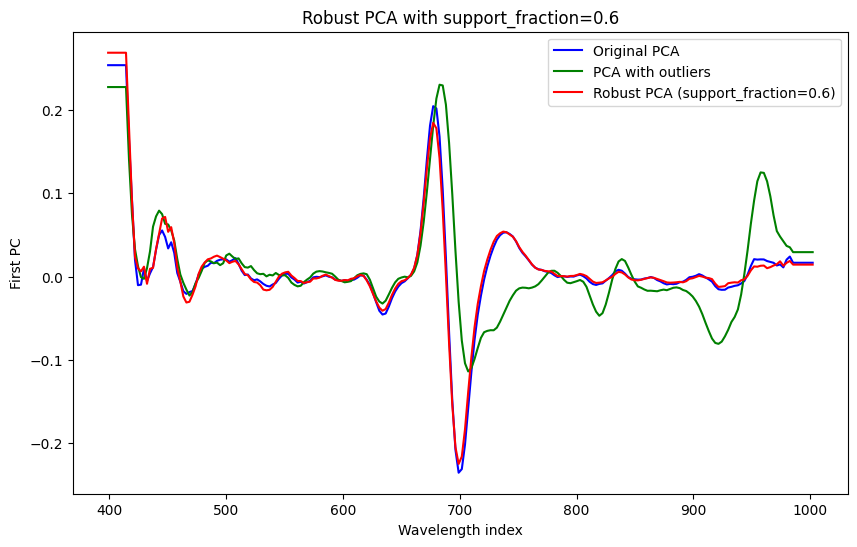

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


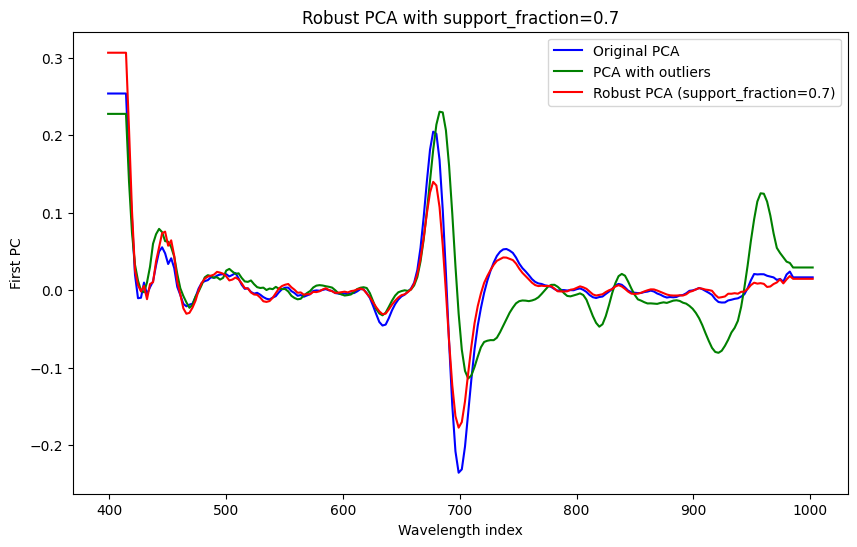

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


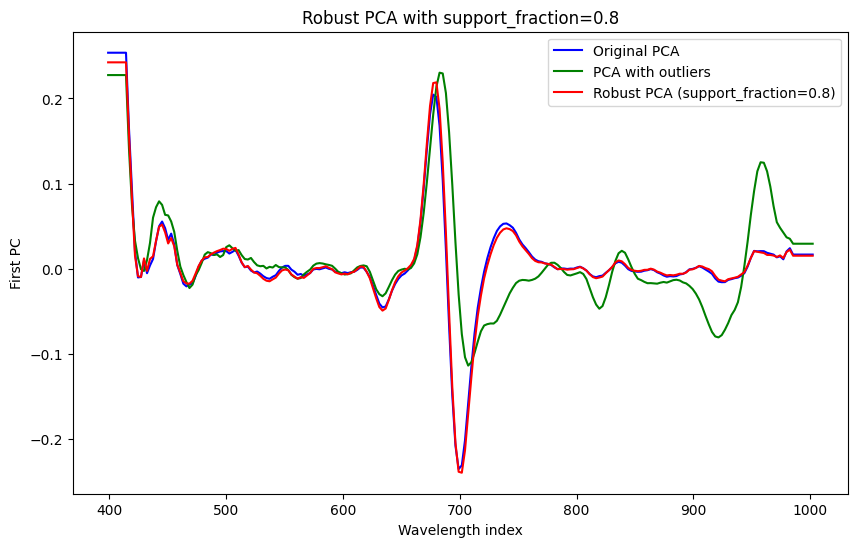

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


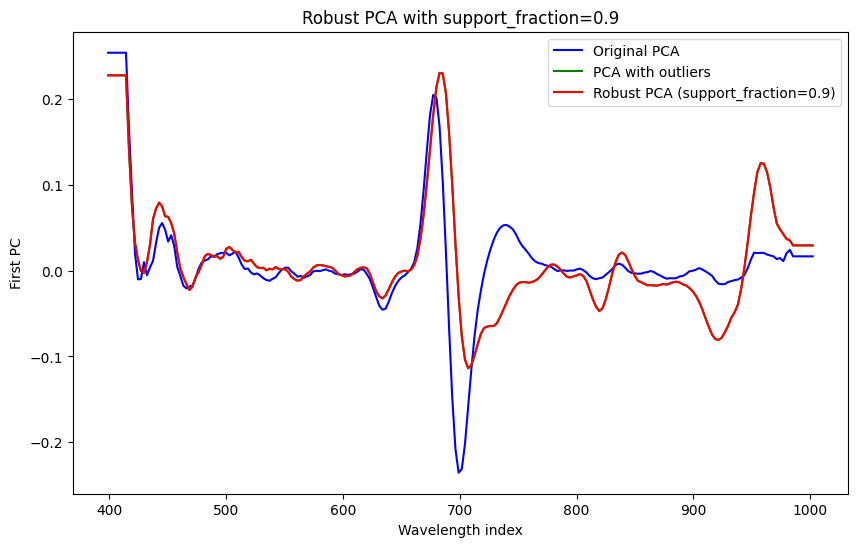

In [21]:
from sklearn.covariance import MinCovDet

for support_fraction_10 in range(1,10):
    support_fraction = support_fraction_10/10
    robust_cov = MinCovDet(support_fraction=support_fraction, random_state=1).fit(X_copy)
    V_robust = robust_cov.covariance_

    values_robust, vectors_robust = np.linalg.eig(V_robust)
    sorted_values_robust = np.argsort(values_robust)[::-1]
    sorted_vectors_robust = vectors_robust[:, sorted_values_robust]

    first_pc_robust = sorted_vectors_robust[:, 0]
    first_pc_robust /= np.linalg.norm(first_pc_robust)
    first_pc_robust *= -1  # Adjust the sign if necessary

    plt.figure(figsize=(10, 6))
    plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
    plt.plot(wl, pipe2["pca"].components_[0], 'g', label="PCA with outliers")
    plt.plot(wl, first_pc_robust, 'r', label=f"Robust PCA (support_fraction={support_fraction})")
    plt.ylabel("First PC")
    plt.xlabel("Wavelength index")
    plt.legend()
    plt.title(f"Robust PCA with support_fraction={support_fraction}")
    plt.show()

In [22]:
# Fit MinCovDet on the data with outliers
robust_cov = MinCovDet(support_fraction=0.8, random_state=1).fit(X_copy)
V_robust = robust_cov.covariance_

# Calculate eigenvalues and eigenvectors of the robust covariance matrix
values_robust, vectors_robust = np.linalg.eig(V_robust)
sorted_values_robust = np.argsort(values_robust)[::-1]
sorted_vectors_robust = vectors_robust[:, sorted_values_robust]

first_pc_robust = sorted_vectors_robust[:, 0]
first_pc_robust /= np.linalg.norm(first_pc_robust)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


In [23]:
first_pc_robust *= -1 # Eigenvectors are unique up to a sign. Sometimes you might want to flip it

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


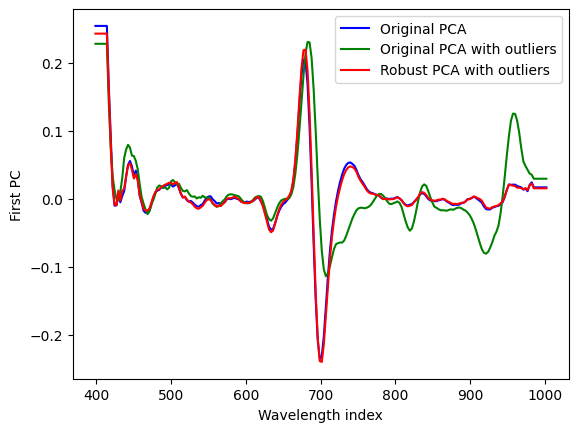

In [24]:
plt.plot(wl, pipe1["pca"].components_[0], 'b', label="Original PCA")
plt.plot(wl, pipe2["pca"].components_[0], 'g', label="Original PCA with outliers")
plt.plot(wl, first_pc_robust, 'r', label="Robust PCA with outliers")
plt.ylabel("First PC")
plt.xlabel("Wavelength index")
 
plt.legend()
plt.show()

In [25]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import root_mean_squared_error, r2_score

def simple_regression(X,y):
 
    # Create linear regression object
    regr = linear_model.LinearRegression()
 
    # Fit
    regr.fit(X, y)
 
    # Calibration
    y_c = regr.predict(X)
 
    # Cross-validation
    y_cv = cross_val_predict(regr, X, y, cv=10)
 
    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)
 
    # Calculate mean square error for calibration and cross validation
    rmse_c = root_mean_squared_error(y, y_c)
    rmse_cv = root_mean_squared_error(y, y_cv)
 
    return(y_cv, score_c, score_cv, rmse_c, rmse_cv)

def pcr(X,y, pc):
 
    ''' Step 1: PCA on input data'''
 
    # Define the PCA object
    pca = PCA()
 
    # Preprocess (2) Standardize features by removing the mean and scaling to unit variance
    Xstd = StandardScaler().fit_transform(X)
 
    # Run PCA producing the reduced variable Xred and select the first pc components
    Xreg = pca.fit_transform(Xstd)[:,:pc]
 
    ''' Step 2: regression on selected principal components'''
 
    y_cv, score_c, score_cv, rmse_c, rmse_cv = simple_regression(Xreg, y)
 
    return(y_cv, score_c, score_cv, rmse_c, rmse_cv)

def robust_pcr_with_test_predefined(X_train, X_test, y_train, y_test, pc, support_fraction=0.7):
    ''' Step 1: Robust PCA on training data'''

    # Standardize the training data
    scaler = StandardScaler()
    X_train_std = scaler.fit_transform(X_train)

    # Fit MinCovDet to estimate robust covariance matrix on training data
    robust_cov = MinCovDet(support_fraction=support_fraction).fit(X_train_std)
    V_robust = robust_cov.covariance_

    # Symmetrize the covariance matrix to avoid complex eigenvalues
    V_robust_sym = (V_robust + V_robust.T) / 2

    # Calculate eigenvalues and eigenvectors of the robust covariance matrix
    values_robust, vectors_robust = np.linalg.eig(V_robust_sym)

    # Ensure eigenvalues are real and non-negative
    values_robust = np.real(values_robust)
    values_robust[values_robust < 0] = 0  # Replace negative eigenvalues with zero

    # Sort eigenvalues and eigenvectors in descending order
    sorted_indices = np.argsort(values_robust)[::-1]
    sorted_values = values_robust[sorted_indices]
    sorted_vectors = vectors_robust[:, sorted_indices]

    # Select the top 'pc' principal components, taking the real part to avoid complex numbers
    components = np.real(sorted_vectors[:, :pc])

    # Transform the standardized training data onto the selected principal components
    X_train_reg = np.real(X_train_std @ components)

    # Standardize the test data using the same scaler fitted on the training data
    X_test_std = scaler.transform(X_test)

    # Transform the standardized test data onto the selected principal components
    X_test_reg = np.real(X_test_std @ components)

    ''' Step 2: regression on selected principal components'''

    # Fit the regression model on the training data
    regr = linear_model.LinearRegression()
    regr.fit(X_train_reg, y_train)

    # Calibration on training data
    y_train_c = regr.predict(X_train_reg)
    score_train_c = r2_score(y_train, y_train_c)
    rmse_train_c = root_mean_squared_error(y_train, y_train_c)

    # Cross-validation on training data
    y_train_cv = cross_val_predict(regr, X_train_reg, y_train, cv=10)
    score_train_cv = r2_score(y_train, y_train_cv)
    rmse_train_cv = root_mean_squared_error(y_train, y_train_cv)

    # Prediction on test data
    y_test_pred = regr.predict(X_test_reg)
    score_test = r2_score(y_test, y_test_pred)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    return y_train_cv, score_train_c, score_train_cv, rmse_train_c, rmse_train_cv, y_test_pred, score_test, rmse_test
    


In [14]:
from sklearn.metrics import r2_score, root_mean_squared_error

def plot_cv_vs_test(y_cal, y_cv, y_test, y_test_pred, plot_titles=["Cross-Validated Predictions", "Test Predictions"]):
    """
    Plot a comparison of cross-validated vs. test set predictions.

    Parameters
    ----------
    y_cal : array-like, shape (n_samples_cal,)
        True target values for the calibration (training) set.
    y_cv : array-like, shape (n_samples_cal,)
        Cross-validated predicted values for the calibration set.
    y_test : array-like, shape (n_samples_test,)
        True target values for the test set.
    y_test_pred : array-like, shape (n_samples_test,)
        Predicted values for the test set.
    plot_titles : list of str (2), optional
        Plot titles to use.
    """
    # Compute metrics
    r2_cv = r2_score(y_cal, y_cv)
    rmse_cv = root_mean_squared_error(y_cal, y_cv)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)

    # Prepare figure
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Combined axis limits
    all_actual = np.concatenate([y_cal, y_test])
    all_pred = np.concatenate([y_cv, y_test_pred])
    vmin = min(all_actual.min(), all_pred.min())*0.95
    vmax = max(all_actual.max(), all_pred.max())*1.05

    # Plot CV
    axs[0].scatter(y_cal, y_cv, alpha=0.6)
    axs[0].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[0].set_title(plot_titles[0])
    axs[0].set_xlabel('Actual')
    axs[0].set_ylabel('Predicted')
    axs[0].set_aspect('equal', 'box')
    axs[0].text(0.05, 0.95, f"R² = {r2_cv:.2f}\nRMSE = {rmse_cv:.2f}",
                transform=axs[0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Plot Test
    axs[1].scatter(y_test, y_test_pred, alpha=0.6, color='orange')
    axs[1].plot([vmin, vmax], [vmin, vmax], 'k--', lw=2)
    axs[1].set_title(plot_titles[1])
    axs[1].set_xlabel('Actual')
    axs[1].set_ylabel('Predicted')
    axs[1].set_aspect('equal', 'box')
    axs[1].text(0.05, 0.95, f"R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}",
                transform=axs[1].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Set same limits
    for ax in axs:
        ax.set_xlim(vmin, vmax)
        ax.set_ylim(vmin, vmax)

    plt.tight_layout()
    plt.show()

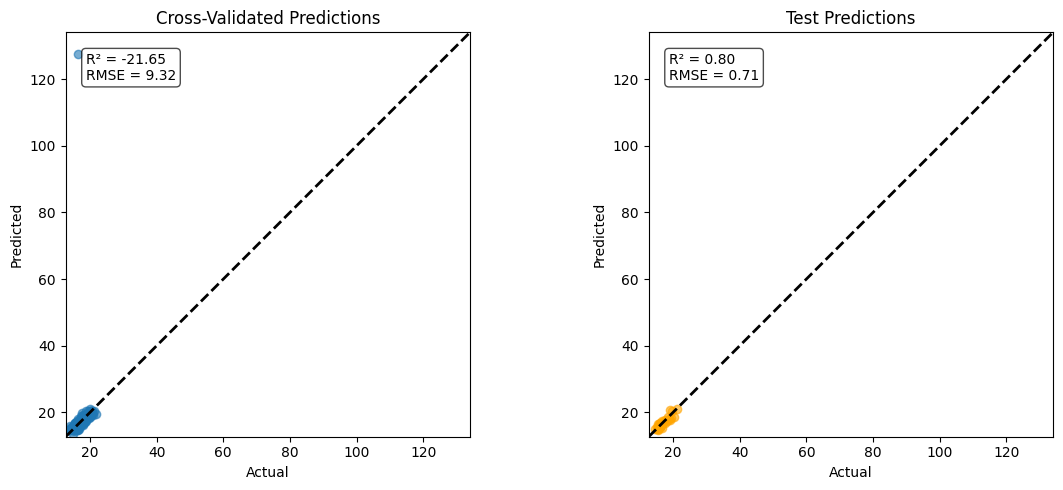

In [26]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_predict

pca = PCA()
pc=20
standard_scaler_cal = StandardScaler()
Xstd = standard_scaler_cal.fit_transform(X_copy)
Xreg = pca.fit_transform(Xstd)[:,:pc]
# Cross-validation prediction on training set
y_cv = cross_val_predict(linear_model.LinearRegression(), Xreg, y_cal_ks, cv=10)

X_test_std = standard_scaler_cal.transform(X_test_ks)
X_test_reg = pca.transform(X_test_std)[:,:pc]

# Fit model on full calibration set
model = linear_model.LinearRegression()
model.fit(Xreg, y_cal_ks)

# Predict on test set
y_test_pred = model.predict(X_test_reg)

plot_cv_vs_test(y_cal_ks, y_cv, y_test_ks, y_test_pred)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


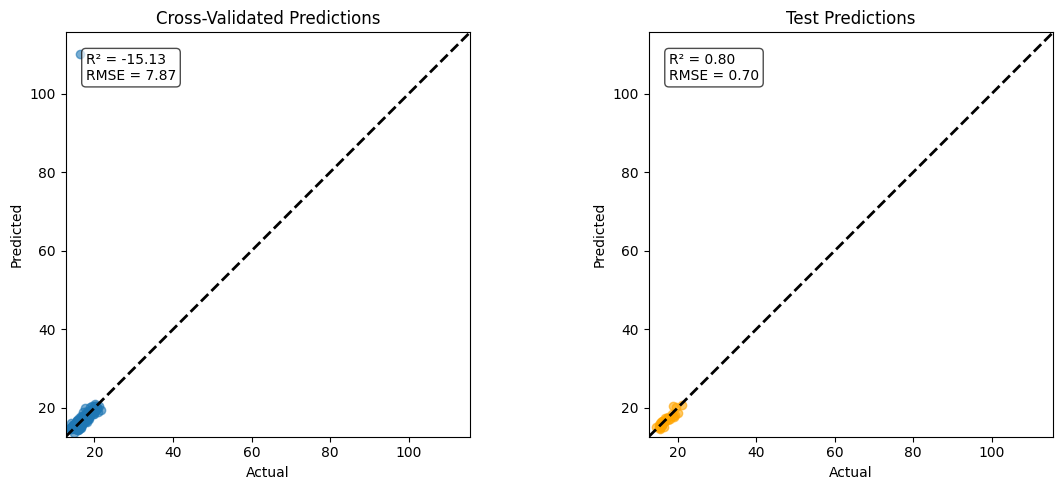

In [16]:
y_train_cv, score_train_c, score_train_cv, rmse_train_c, rmse_train_cv, y_test_pred, score_test, rmse_test = robust_pcr_with_test_predefined(X_copy, X_test_ks, y_cal_ks, y_test_ks, pc=20)
plot_cv_vs_test(y_cal_ks, y_train_cv, y_test_ks, y_test_pred)

## Robust PLSR

using https://github.com/puneetmishra2/IRNPLS/tree/main

In [17]:
import numpy as np

def irpls(X, Y, lvs, alpha):
    """
    Python implementation of the MATLAB function irpls.

    Parameters:
    - X: Predictor matrix (n_samples, n_features)
    - Y: Response matrix (n_samples, 1)  # Assuming single response for now
    - lvs: Number of latent variables
    - alpha: Parameter for the algorithm

    Returns:
    - beta: Regression coefficients (including intercept)
    - weights: Weights matrix (lvs, n_samples)
    - attributes: Dictionary containing intermediate results ('T', 'Pb', 'W', 'PtW')
    """
    # Check that X and Y have the same number of samples
    if X.shape[0] != Y.shape[0]:
        raise ValueError("X and Y must have the same number of samples (rows).")

    # Check that Y has a single response column
    if Y.ndim == 1:
        Y = Y.reshape(-1, 1)  # Ensure Y is 2D with shape (n_samples, 1)
    elif Y.shape[1] != 1:
        raise ValueError("This implementation assumes Y has a single response column.")

    Xorig = X.copy()
    yorig = Y.copy()
    X = X - np.median(X, axis=0)
    Y = Y - np.median(Y, axis=0)

    n_samples, n_features = X.shape
    n_responses = Y.shape[1]
    lvs = min(lvs, n_samples, n_features)  # Ensure lvs is not larger than dimensions allow
    q = np.zeros((n_responses, lvs))
    T = np.zeros((n_samples, lvs))
    weights = np.zeros((lvs, n_samples))  # n_samples is X.shape[0]
    w = np.zeros((n_features, lvs))
    Pb = np.zeros((n_features, lvs))

    for i in range(lvs):
        D = np.eye(n_samples) * (1 / n_samples)
        crit = 1
        while crit > 10e-5:
            vt = X.T @ D @ Y
            v = vt.copy()
            t_temp = X @ v / np.linalg.norm(X @ v)
            q_temp = (Y.T @ D) @ t_temp
            r = Y - np.outer(t_temp, q_temp.T)
            lo = 1 - np.diag(np.outer(t_temp, t_temp))
            r = r / np.sqrt(lo[:, np.newaxis])
            mad_r = np.median(np.abs(r - np.median(r, axis=0)), axis=0)
            r = r * (0.6745 / alpha) / mad_r
            temp_D = (1 - r**2)**2
            temp_D[np.abs(r) >= 1] = 0
            temp_D = np.prod(temp_D, axis=1)
            crit = np.sum(np.abs(temp_D) - np.abs(np.diag(D)))
            D = np.diag(temp_D)

        # Check that the length of diag(D) matches n_samples
        if len(np.diag(D)) != n_samples:
            raise ValueError(f"Expected diag(D) to have length {n_samples}, but got {len(np.diag(D))}.")

        weights[i, :] = np.diag(D)
        vt = X.T @ D @ Y
        # Ensure vt is a 1D array of length n_features
        if vt.ndim == 2 and vt.shape[1] == 1:
            vt = vt.flatten()  # Convert (n_features, 1) to (n_features,)
        w[:, i] = vt
        t = X @ w[:, i] / np.linalg.norm(X @ w[:, i])
        t = t / np.linalg.norm(t)
        T[:, i] = t
        q[:, i] = (Y.T @ D) @ t
        Pb[:, i] = (X.T @ D) @ t
        X = X - np.outer(t, Pb[:, i].T)
        Y = Y - np.outer(t, q[:, i].T)
        w[:, i] = w[:, i] / np.linalg.norm(w[:, i])

    PtW = np.triu(Pb.T @ w)
    beta = []
    for i in range(n_responses):
        w_div_PtW = w / PtW.diagonal()[np.newaxis, :]
        temp = w_div_PtW * q[i, np.newaxis, :]
        temp_cumsum = np.cumsum(temp, axis=1)
        beta_i = temp_cumsum[:, -1]
        intercept = np.median(yorig[:, i]) - np.median(Xorig, axis=0) @ beta_i
        beta_i_full = np.concatenate(([intercept], beta_i))
        beta.append(beta_i_full)

    attributes = {
        'T': T,
        'Pb': Pb,
        'W': w,
        'PtW': PtW
    }

    return beta, weights, attributes


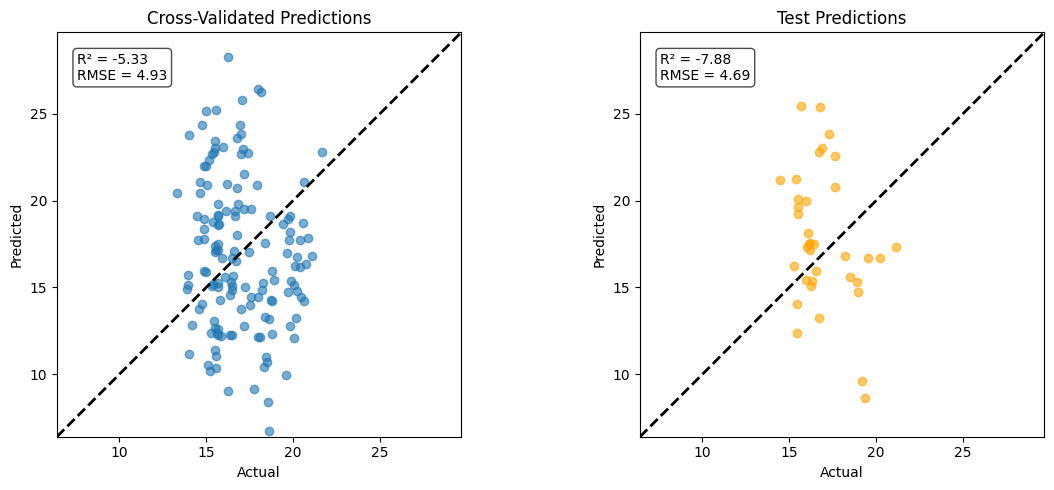

In [36]:
np.expand_dims(reference_values, axis=0)

beta, weights, attributes = irpls(Xstd, y_cal_ks, lvs=60, alpha=0.2)

n_samples_new = Xstd.shape[0]
n_responses = len(beta)

Y_pred_train = np.zeros((n_samples_new, n_responses))

for i in range(n_responses):
    # beta_i is [intercept, beta_1, ..., beta_p]
    intercept = beta[i][0]
    coef = beta[i][1:]  # coefficients for features
    Y_pred_train[:, i] = intercept + Xstd @ coef

n_samples_new = X_test_std.shape[0]
n_responses = len(beta)
Y_pred_test = np.zeros((n_samples_new, n_responses))

for i in range(n_responses):
    # beta_i is [intercept, beta_1, ..., beta_p]
    intercept = beta[i][0]
    coef = beta[i][1:]  # coefficients for features
    Y_pred_test[:, i] = intercept + X_test_std @ coef


plot_cv_vs_test(y_cal_ks, Y_pred_train, y_test_ks, Y_pred_test)

Beta coefficients: [array([-0.39495008, -0.46812903, -0.04334511, -0.15391531, -0.20602155,
        0.48912897])]
Weights shape: (3, 100)
Attributes keys: dict_keys(['T', 'Pb', 'W', 'PtW'])
Predicted vs Actual comparison:
[[ 3.20916154e+01 -9.36937406e-01]
 [ 3.23435318e+00  2.66757500e-01]
 [ 1.20762477e+01 -4.50513379e-01]
 [ 1.74629531e+00 -1.06659841e+00]
 [ 1.11855785e+01  1.90190216e+00]
 [ 1.39017306e+01  7.15628156e-01]
 [-1.32614793e+01 -1.09320298e-01]
 [ 5.90586201e+00 -7.74600693e-01]
 [-5.60419241e+00 -2.31107462e-01]
 [-9.74036137e+00 -2.67995952e-02]
 [-7.65617444e+00  3.15545143e-01]
 [-1.94445806e+00 -6.91646110e-01]
 [-1.23762428e+01  5.03024397e-01]
 [-7.26470981e+00  4.89810787e-03]
 [ 3.57664771e+00 -4.66022854e-01]
 [-6.50059900e+00  1.44126664e-01]
 [ 4.53299330e+00  1.08421794e+00]
 [ 8.68616219e+00 -5.69510999e-01]
 [ 1.17439028e+01 -3.18154535e-01]
 [ 1.28088919e+01 -8.30567421e-01]
 [-6.57293324e+00 -1.79606698e+00]
 [ 1.90630571e+01 -8.43847315e-01]
 [ 1.178

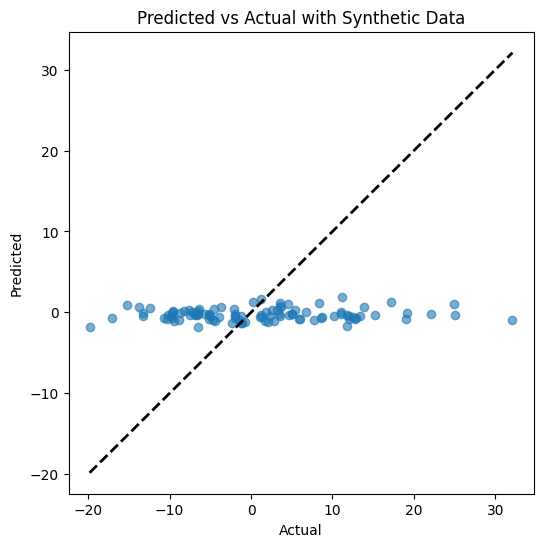

In [38]:
import numpy as np

def test_irpls_with_synthetic_data():
    # Create synthetic data
    np.random.seed(0)
    n_samples = 100
    n_features = 5
    X = np.random.randn(n_samples, n_features)
    true_beta = np.array([1, 2, 3, 4, 5, 6])  # true coefficients
    noise = np.random.randn(n_samples) * 0.1  # add some noise
    Y = X @ true_beta[1:] + true_beta[0] + noise
    Y = Y.reshape(-1, 1)  # Ensure Y is 2D

    lvs = 3
    alpha = 0.05

    # Call the function with synthetic data
    beta, weights, attributes = irpls(X, Y, lvs=lvs, alpha=alpha)

    # Print results
    print("Beta coefficients:", beta)
    print("Weights shape:", weights.shape)
    print("Attributes keys:", attributes.keys())

    # Simulate prediction
    n_responses = len(beta)
    Y_pred = np.zeros((n_samples, n_responses))

    for i in range(n_responses):
        intercept = beta[i][0]
        coef = beta[i][1:]  # coefficients for features
        Y_pred[:, i] = intercept + X @ coef

    # Print and plot results
    print("Predicted vs Actual comparison:")
    print(np.c_[Y.flatten(), Y_pred.flatten()])

    # Plotting
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 6))
    plt.scatter(Y, Y_pred, alpha=0.6)
    plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'k--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs Actual with Synthetic Data')
    plt.show()

# Call the test function
test_irpls_with_synthetic_data()

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:167: FutureWarning: `Y` is deprecated in 1.5 and will be removed in 1.7. Use `y` instead.
  warnings.warn(


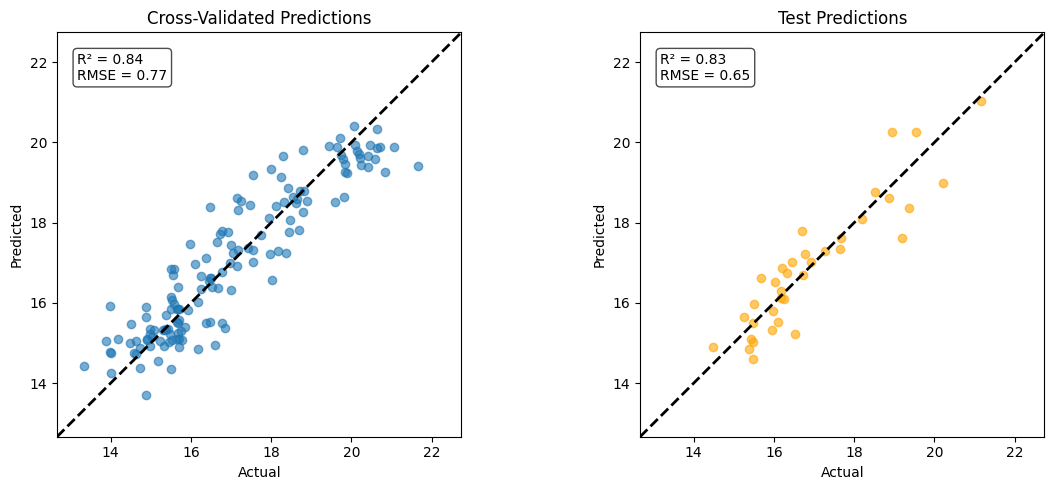

In [27]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=5)
pls.fit(X=X_copy, Y=y_cal_ks)
y_pred_pls_cv = pls.predict(X_copy)
y_pred_pls_test = pls.predict(X_test_ks)
plot_cv_vs_test(y_cal_ks, y_pred_pls_cv, y_test_ks, y_pred_pls_test)